# Fundamentos de Redes Neuronales de Grafos (GNN)

En este notebook vamos a:

1. Entender por qué las redes convolucionales clásicas (CNN) no sirven directamente para datos con estructura de grafo.
2. Definir formalmente un grafo y explorar sus propiedades.
3. Construir la intuición del **paso de mensajes** con una analogía de red social.
4. Entender por qué la **invarianza a permutaciones** es fundamental.
5. Implementar desde cero un paso de mensajes con NumPy y visualizar como cambian las representaciones de los nodos.

In [1]:
# Dependencias
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx

# Semilla para reproducibilidad
np.random.seed(42)

# Estilo de gráficas
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

---
## 1. Introducción al dominio de grafos

### Datos euclidianos vs. datos relacionales

Las **redes convolucionales (CNN)** fueron diseñadas para datos que viven en **cuadriculas regulares**: imágenes (2D), señales de audio (1D), videos (3D). En una imagen, la estructura de vecindad es regular y predecible: los pixeles interiores comparten el mismo patrón local de vecinos, mientras que los de borde y esquina son casos especiales. Además, existe un orden espacial claro.

Pero muchos datos **no** tienen esta estructura regular:

| Dato | Estructura |
|------|------------|
| Moléculas | Átomos conectados por enlaces |
| Redes sociales | Personas conectadas por amistades |
| Internet | Páginas conectadas por hipervinculos |
| Proteinas | Aminoácidos en interacción 3D |

Estos datos se representan naturalmente como **grafos**.

### Definición formal

Un grafo se define como $G = (V, E)$, donde:
- $V$ es el conjunto de **nodos** (o vértices)
- $E \subseteq V \times V$ es el conjunto de **aristas** (o enlaces)

**Diferencias clave con las cuadriculas:**
1. El **número de vecinos varia** por nodo (un nodo puede tener 1 vecino, otro puede tener 100).
2. **No existe un orden topológico estricto** (no hay un "arriba" o "abajo" universal).
3. No podemos aplicar directamente un kernel convolucional de tamaño fijo.

### Visualización: cuadricula vs. grafo

Vamos a visualizar lado a lado una cuadricula regular (como la de una imagen) y un grafo irregular (como una red social) para apreciar la diferencia estructural.

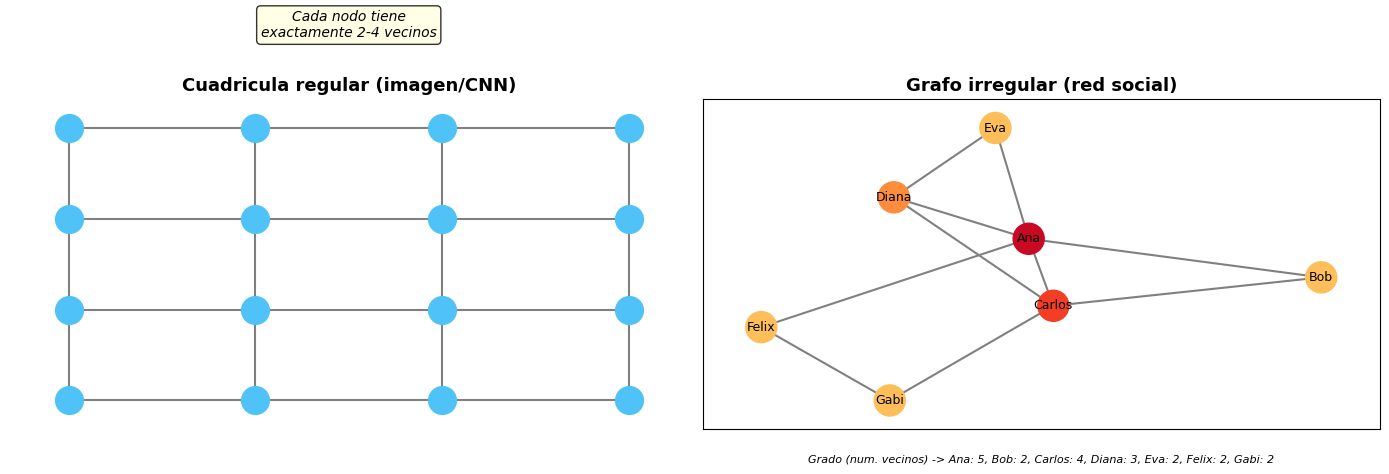

Observacion: En la cuadricula, la estructura es homogenea.
En el grafo, Ana tiene 5 vecinos pero Eva solo tiene 2.
No hay un 'arriba' o 'abajo' definido — el layout es arbitrario.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Cuadricula regular (como una imagen) ---
grid = nx.grid_2d_graph(4, 4)
pos_grid = {(i, j): (j, -i) for i, j in grid.nodes()}

ax = axes[0]
ax.set_title('Cuadricula regular (imagen/CNN)', fontsize=13, fontweight='bold')
nx.draw(grid, pos=pos_grid, ax=ax, node_color='#4FC3F7', node_size=400,
        edge_color='gray', width=1.5, with_labels=False)
ax.text(1.5, 1.0, 'Cada nodo tiene\nexactamente 2-4 vecinos', 
        ha='center', fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Grafo irregular (red social) ---
G_social = nx.Graph()
nombres = ['Ana', 'Bob', 'Carlos', 'Diana', 'Eva', 'Felix', 'Gabi']
G_social.add_nodes_from(nombres)
aristas = [
    ('Ana', 'Bob'), ('Ana', 'Carlos'), ('Ana', 'Diana'),
    ('Ana', 'Eva'), ('Ana', 'Felix'),  # Ana es muy social
    ('Bob', 'Carlos'),
    ('Carlos', 'Diana'), ('Carlos', 'Gabi'),
    ('Diana', 'Eva'),
    ('Felix', 'Gabi'),
]
G_social.add_edges_from(aristas)

pos_social = nx.spring_layout(G_social, seed=42)

# Colorear nodos según su grado (número de vecinos)
grados = [G_social.degree(n) for n in G_social.nodes()]

ax = axes[1]
ax.set_title('Grafo irregular (red social)', fontsize=13, fontweight='bold')
nodos = nx.draw_networkx_nodes(G_social, pos=pos_social, ax=ax, 
                                node_color=grados, cmap=plt.cm.YlOrRd,
                                node_size=500, vmin=0, vmax=6)
nx.draw_networkx_edges(G_social, pos=pos_social, ax=ax, edge_color='gray', width=1.5)
nx.draw_networkx_labels(G_social, pos=pos_social, ax=ax, font_size=9)

# Leyenda con los grados
grado_texto = ', '.join([f'{n}: {G_social.degree(n)}' for n in nombres])
ax.text(0.5, -0.1, f'Grado (num. vecinos) -> {grado_texto}',
        ha='center', transform=ax.transAxes, fontsize=8, style='italic')

plt.tight_layout()
plt.show()

print("Observacion: En la cuadricula, la estructura es homogenea.")
print("En el grafo, Ana tiene 5 vecinos pero Eva solo tiene 2.")
print("No hay un 'arriba' o 'abajo' definido — el layout es arbitrario.")

---
## 2. El paradigma del Paso de Mensajes (*Message Passing*)

### Intuicion: la red social

Imaginemos que cada persona en una red social tiene un **estado interno** (sus opiniones, intereses, conocimientos). En cada "ronda" de interacción:

1. Cada persona **recoge información** de sus amigos directos.
2. **Agrega** esa información (la resume de alguna forma).
3. **Actualiza** su propio estado combinando lo que ya sabia con lo que aprendio de sus amigos.

Este es exactamente el mecanismo de **paso de mensajes** en una GNN:

$$h_v^{(k)} = \sigma \left( W^{(k)} \cdot \text{COMBINE} \left( h_v^{(k-1)}, \text{AGG} \left( \{ h_u^{(k-1)} \}_{u \in \mathcal{N}(v)} \right) \right) \right)$$

Donde:
- $h_v^{(k)}$ es la representación del nodo $v$ en la capa $k$
- $\mathcal{N}(v)$ son los vecinos de $v$
- $\text{AGG}$ agrega la información de los vecinos (ej. suma, promedio, máximo)
- $\text{COMBINE}$ combina la información propia con la agregada
- $W^{(k)}$ es una matriz de pesos aprendible
- $\sigma$ es una función de activación no lineal (ej. ReLU)

### Pero hay un requisito fundamental: la invarianza a permutaciones

---
## 3. Invarianza a permutaciones: por qué el orden no debe importar

Pensemos en Ana y sus 5 amigos en la red social de arriba. Si queremos resumir la información de sus amigos, el resultado **no debería depender del orden** en que los enumeramos.

> *"Si ordeno a tus amigos de Facebook alfabeticamente o por edad, el resumen de tu entorno social debería ser exactamente el mismo."*  
> (cf. Aggarwal, *Neural Networks and Deep Learning*, §10.3.1)

Esto se llama **invarianza a las permutaciones** (*permutation invariance*).

La concatenación falla por **dos razones**:
1. **Depende del orden:** concatenar `[a, b, c]` da un resultado distinto a `[c, a, b]`.
2. **Produce vectores de tamaño variable:** Ana tiene 5 amigos (vector de 15 dimensiones al concatenar), pero Eva solo tiene 2 (vector de 6 dimensiones). Las redes neuronales tradicionales (MLPs, CNNs) requieren entradas de **tamaño fijo**. Las operaciones de agregación (suma, media, máximo) resuelven ambos problemas: son invariantes al orden y colapsan cualquier número de vecinos en un único vector de tamaño fijo.

Vamos a demostrar con código por qué la **concatenación falla** y por qué necesitamos operaciones como **suma, media o máximo**.

In [3]:
# Supongamos que los amigos de Ana tienen estos vectores de características
# (cada vector representa los "intereses" de una persona en 3 dimensiones)

amigos = {
    'Bob':    np.array([0.8, 0.1, 0.3]),
    'Carlos': np.array([0.2, 0.9, 0.1]),
    'Diana':  np.array([0.5, 0.5, 0.7]),
    'Eva':    np.array([0.1, 0.3, 0.9]),
    'Felix':  np.array([0.6, 0.2, 0.4]),
}

print("Vectores de características de los amigos de Ana:")
for nombre, vec in amigos.items():
    print(f"  {nombre}: {vec}")

print("\n" + "="*60)
print("COMPARACIÓN: Concatenación vs. Operaciones invariantes")
print("="*60)

Vectores de características de los amigos de Ana:
  Bob: [0.8 0.1 0.3]
  Carlos: [0.2 0.9 0.1]
  Diana: [0.5 0.5 0.7]
  Eva: [0.1 0.3 0.9]
  Felix: [0.6 0.2 0.4]

COMPARACIÓN: Concatenación vs. Operaciones invariantes


In [4]:
# --- CONCATENACIÓN: depende del orden ---
# Orden 1: alfabético
orden_1 = ['Bob', 'Carlos', 'Diana', 'Eva', 'Felix']
concat_1 = np.concatenate([amigos[n] for n in orden_1])

# Orden 2: invertido
orden_2 = ['Felix', 'Eva', 'Diana', 'Carlos', 'Bob']
concat_2 = np.concatenate([amigos[n] for n in orden_2])

# Orden 3: aleatorio
orden_3 = ['Diana', 'Bob', 'Felix', 'Eva', 'Carlos']
concat_3 = np.concatenate([amigos[n] for n in orden_3])

print("CONCATENACIÓN (NO es invariante a permutaciones):")
print(f"  Orden alfabetico:  {concat_1}")
print(f"  Orden invertido:   {concat_2}")
print(f"  Orden aleatorio:   {concat_3}")
print(f"  Son iguales? {np.allclose(concat_1, concat_2)} ")
print()

# --- OPERACIONES INVARIANTES ---
vectores = list(amigos.values())

# Creamos permutaciones distintas de los vectores
perm_1 = [amigos[n] for n in orden_1]
perm_2 = [amigos[n] for n in orden_2]
perm_3 = [amigos[n] for n in orden_3]

print("SUMA (SI es invariante):")
suma_1 = np.sum(perm_1, axis=0)
suma_2 = np.sum(perm_2, axis=0)
suma_3 = np.sum(perm_3, axis=0)
print(f"  Orden 1: {suma_1}")
print(f"  Orden 2: {suma_2}")
print(f"  Orden 3: {suma_3}")
print(f"  Todas iguales? {np.allclose(suma_1, suma_2) and np.allclose(suma_2, suma_3)}")
print()

print("MEDIA (SI es invariante):")
media_1 = np.mean(perm_1, axis=0)
media_2 = np.mean(perm_2, axis=0)
media_3 = np.mean(perm_3, axis=0)
print(f"  Orden 1: {media_1}")
print(f"  Orden 2: {media_2}")
print(f"  Orden 3: {media_3}")
print(f"  Todas iguales? {np.allclose(media_1, media_2) and np.allclose(media_2, media_3)}")
print()

print("MAXIMO (SI es invariante):")
max_1 = np.max(perm_1, axis=0)
max_2 = np.max(perm_2, axis=0)
max_3 = np.max(perm_3, axis=0)
print(f"  Orden 1: {max_1}")
print(f"  Orden 2: {max_2}")
print(f"  Orden 3: {max_3}")
print(f"  Todas iguales? {np.allclose(max_1, max_2) and np.allclose(max_2, max_3)}")

CONCATENACION (NO es invariante a permutaciones):
  Orden alfabetico:  [0.8 0.1 0.3 0.2 0.9 0.1 0.5 0.5 0.7 0.1 0.3 0.9 0.6 0.2 0.4]
  Orden invertido:   [0.6 0.2 0.4 0.1 0.3 0.9 0.5 0.5 0.7 0.2 0.9 0.1 0.8 0.1 0.3]
  Orden aleatorio:   [0.5 0.5 0.7 0.8 0.1 0.3 0.6 0.2 0.4 0.1 0.3 0.9 0.2 0.9 0.1]
  Son iguales? False 

SUMA (SI es invariante):
  Orden 1: [2.2 2.  2.4]
  Orden 2: [2.2 2.  2.4]
  Orden 3: [2.2 2.  2.4]
  Todas iguales? True

MEDIA (SI es invariante):
  Orden 1: [0.44 0.4  0.48]
  Orden 2: [0.44 0.4  0.48]
  Orden 3: [0.44 0.4  0.48]
  Todas iguales? True

MAXIMO (SI es invariante):
  Orden 1: [0.8 0.9 0.9]
  Orden 2: [0.8 0.9 0.9]
  Orden 3: [0.8 0.9 0.9]
  Todas iguales? True


---
## 4. Implementación desde cero: paso de mensajes con NumPy

Ahora vamos a implementar un paso de mensajes completo. Usaremos una versión simplificada de la ecuación general:

$$h_v^{(k)} = \text{ReLU} \left( W^{(k)} \cdot \left[ h_v^{(k-1)} + \sum_{u \in \mathcal{N}(v)} h_u^{(k-1)} \right] \right)$$

Es decir:
- **AGG** = suma de los vecinos
- **COMBINE** = suma del propio nodo con la agregación de vecinos
- Transformacion lineal con $W^{(k)}$
- Activacion con ReLU

### Paso 1: Crear el grafo y asignar características iniciales

In [6]:
# Creamos un grafo pequeño: una red social simplificada
G = nx.Graph()

# 7 nodos con nombres
nodos = ['Ana', 'Bob', 'Carlos', 'Diana', 'Eva', 'Felix', 'Gabi']
G.add_nodes_from(nodos)

# Definimos las conexiones (aristas)
aristas = [
    ('Ana', 'Bob'), ('Ana', 'Carlos'), ('Ana', 'Diana'),
    ('Bob', 'Carlos'), ('Bob', 'Eva'),
    ('Carlos', 'Diana'), ('Carlos', 'Gabi'),
    ('Diana', 'Eva'),
    ('Eva', 'Felix'),
    ('Felix', 'Gabi'),
]
G.add_edges_from(aristas)

# Posiciones fijas para visualización consistente
pos = nx.spring_layout(G, seed=42)

# Matriz de adyacencia
A = nx.adjacency_matrix(G, nodelist=nodos).toarray().astype(float)

print("Matriz de adyacencia A:")
print(f"  Nodos: {nodos}")
print(A)
print(f"\nDimensiones: {A.shape}")
print(f"Numero de aristas: {G.number_of_edges()}")

Matriz de adyacencia A:
  Nodos: ['Ana', 'Bob', 'Carlos', 'Diana', 'Eva', 'Felix', 'Gabi']
[[0. 1. 1. 1. 0. 0. 0.]
 [1. 0. 1. 0. 1. 0. 0.]
 [1. 1. 0. 1. 0. 0. 1.]
 [1. 0. 1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 0. 1. 0.]]

Dimensiones: (7, 7)
Numero de aristas: 10


In [7]:
# Características iniciales de cada nodo (features)
# Cada nodo tiene un vector de 4 dimensiones que representa sus "atributos"
# Por ejemplo: [extroversión, conocimiento técnico, creatividad, liderazgo]

num_nodos = len(nodos)
dim_entrada = 4  # dimensiones de las características

# Asignamos características iniciales (con valores interpretables)
H_0 = np.array([
    [0.9, 0.3, 0.7, 0.8],  # Ana: muy extrovertida y líder
    [0.2, 0.8, 0.4, 0.3],  # Bob: muy técnico
    [0.5, 0.7, 0.6, 0.5],  # Carlos: equilibrado, algo técnico
    [0.6, 0.4, 0.9, 0.7],  # Diana: muy creativa
    [0.3, 0.9, 0.2, 0.4],  # Eva: la más técnica
    [0.7, 0.2, 0.8, 0.6],  # Felix: creativo y extrovertido
    [0.4, 0.6, 0.5, 0.3],  # Gabi: equilibrada
])

print("Características iniciales H^(0):")
print(f"{'Nodo':<10} {'Extrov.':>8} {'Tecnico':>8} {'Creativ.':>8} {'Lider':>8}")
print("-" * 44)
for i, nombre in enumerate(nodos):
    print(f"{nombre:<10} {H_0[i,0]:>8.1f} {H_0[i,1]:>8.1f} {H_0[i,2]:>8.1f} {H_0[i,3]:>8.1f}")

Caracteristicas iniciales H^(0):
Nodo        Extrov.  Tecnico Creativ.    Lider
--------------------------------------------
Ana             0.9      0.3      0.7      0.8
Bob             0.2      0.8      0.4      0.3
Carlos          0.5      0.7      0.6      0.5
Diana           0.6      0.4      0.9      0.7
Eva             0.3      0.9      0.2      0.4
Felix           0.7      0.2      0.8      0.6
Gabi            0.4      0.6      0.5      0.3


### Paso 2: Implementar la función de paso de mensajes

Implementamos la ecuación:

$$H^{(k)} = \text{ReLU}\left( \hat{A} \cdot H^{(k-1)} \cdot W^{(k)} \right)$$

*Esta es la regla de propagación del Graph Convolutional Network (GCN) (Kipf & Welling, 2017).*

Donde $\tilde{A} = A + I_n$ (agregamos auto-conexiones para que cada nodo también considere su propia información).

**Conexión con la fórmula general:** Sumar la matriz identidad $I$ equivale a implementar la función `COMBINE` (cada nodo se incluye a sí mismo en la agregación), mientras que multiplicar por $A$ implementa la función `AGG` (sumar las representaciones de los vecinos). Así, $\tilde{A} = A + I$ unifica ambas operaciones en una sola multiplicacion matricial.

Además, normalizamos por el grado para evitar que nodos con muchos vecinos tengan valores desproporcionadamente grandes:

$$\hat{A} = D^{-1/2} \tilde{A} \, D^{-1/2}$$

donde $D$ es la matriz diagonal de grados de $\tilde{A}$.

In [8]:
def normalizar_adyacencia(A):
    """
    Calcula la normalización simétrica de la matriz de adyacencia:
    A_hat = D^{-1/2} * A_tilde * D^{-1/2}
    donde A_tilde = A + I (con auto-conexiones)
    """
    n = A.shape[0]
    A_tilde = A + np.eye(n)  # Agregar auto-conexiones
    
    # Calcular la matriz de grados D
    D = np.diag(np.sum(A_tilde, axis=1))
    
    # D^{-1/2}
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D)))
    
    # Normalización simétrica
    A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt
    return A_hat


def relu(x):
    """Función de activación ReLU: max(0, x)"""
    return np.maximum(0, x)


def paso_de_mensajes(H, A_hat, W):
    """
    Realiza una ronda de paso de mensajes:
    H_nueva = ReLU(A_hat @ H @ W)
    
    Parámetros:
        H      : (n, d_in)  - Características actuales de los nodos
        A_hat  : (n, n)     - Matriz de adyacencia normalizada
        W      : (d_in, d_out) - Pesos de la capa
    
    Retorna:
        H_nueva : (n, d_out) - Nuevas características de los nodos
    """
    # 1. Agregación: cada nodo recoge info de sus vecinos (y de sí mismo)
    #    Esto es equivalente a: para cada nodo v, sumar las características
    #    ponderadas de sus vecinos
    mensajes_agregados = A_hat @ H
    
    # 2. Transformacion lineal: proyectar a un nuevo espacio
    H_transformada = mensajes_agregados @ W
    
    # 3. No-linealidad
    H_nueva = relu(H_transformada)
    
    return H_nueva


# Calcular la matriz normalizada
A_hat = normalizar_adyacencia(A)

print("Matriz de adyacencia normalizada A_hat:")
print(np.round(A_hat, 3))
print("\nNota: la diagonal ya no es cero (auto-conexiones).")
print("Los valores estan normalizados por los grados de los nodos.")

Matriz de adyacencia normalizada A_hat:
[[0.25  0.25  0.224 0.25  0.    0.    0.   ]
 [0.25  0.25  0.224 0.    0.25  0.    0.   ]
 [0.224 0.224 0.2   0.224 0.    0.    0.258]
 [0.25  0.    0.224 0.25  0.25  0.    0.   ]
 [0.    0.25  0.    0.25  0.25  0.289 0.   ]
 [0.    0.    0.    0.    0.289 0.333 0.333]
 [0.    0.    0.258 0.    0.    0.333 0.333]]

Nota: la diagonal ya no es cero (auto-conexiones).
Los valores estan normalizados por los grados de los nodos.


### Paso 3: Ejecutar múltiples rondas de paso de mensajes

Ahora vamos a ejecutar 3 rondas de paso de mensajes y observar como cambian las representaciones de los nodos. Usaremos matrices de pesos $W$ inicializadas aleatoriamente.

Para poder visualizar los cambios, mantendremos la dimensionalidad en 4 (entrada y salida de cada capa).

In [9]:
# Inicializamos los pesos de 3 capas de mensaje
# Usamos inicializacion Xavier/Glorot para valores razonables
np.random.seed(123)

dim = 4  # mantenemos la misma dimensión para poder comparar
num_capas = 3

# Inicializacion Xavier: var = 2/(n_in + n_out)
pesos = []
for k in range(num_capas):
    escala = np.sqrt(2.0 / (dim + dim))
    W = np.random.randn(dim, dim) * escala
    pesos.append(W)
    print(f"Capa {k+1} - W^({k+1}) shape: {W.shape}")

# Ejecutar las rondas de paso de mensajes
representaciones = [H_0]  # Guardamos H^(0), H^(1), H^(2), H^(3)

H_actual = H_0.copy()
for k in range(num_capas):
    H_actual = paso_de_mensajes(H_actual, A_hat, pesos[k])
    representaciones.append(H_actual)
    print(f"\nDespues de la capa {k+1}:")
    print(f"  Rango de valores: [{H_actual.min():.4f}, {H_actual.max():.4f}]")
    print(f"  Norma promedio por nodo: {np.mean(np.linalg.norm(H_actual, axis=1)):.4f}")

Capa 1 - W^(1) shape: (4, 4)
Capa 2 - W^(2) shape: (4, 4)
Capa 3 - W^(3) shape: (4, 4)

Despues de la capa 1:
  Rango de valores: [0.0000, 0.4179]
  Norma promedio por nodo: 0.4396

Despues de la capa 2:
  Rango de valores: [0.0000, 0.6452]
  Norma promedio por nodo: 0.7629

Despues de la capa 3:
  Rango de valores: [0.0000, 0.2755]
  Norma promedio por nodo: 0.2620


### Paso 4: Visualizar la evolución de las representaciones

Vamos a ver como los vectores de características de los nodos cambian con cada ronda de paso de mensajes. Usaremos dos formas de visualización:

1. **Colores en el grafo:** Cada nodo se colorea según su primera característica (dimensión 0 del vector).
2. **Heatmap:** Mostramos todas las dimensiones de todos los nodos.

A medida que avanzan las rondas, los nodos que estan conectados tienden a volverse más similares (comparten información con sus vecinos).

/tmp/ipykernel_35363/2033401064.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


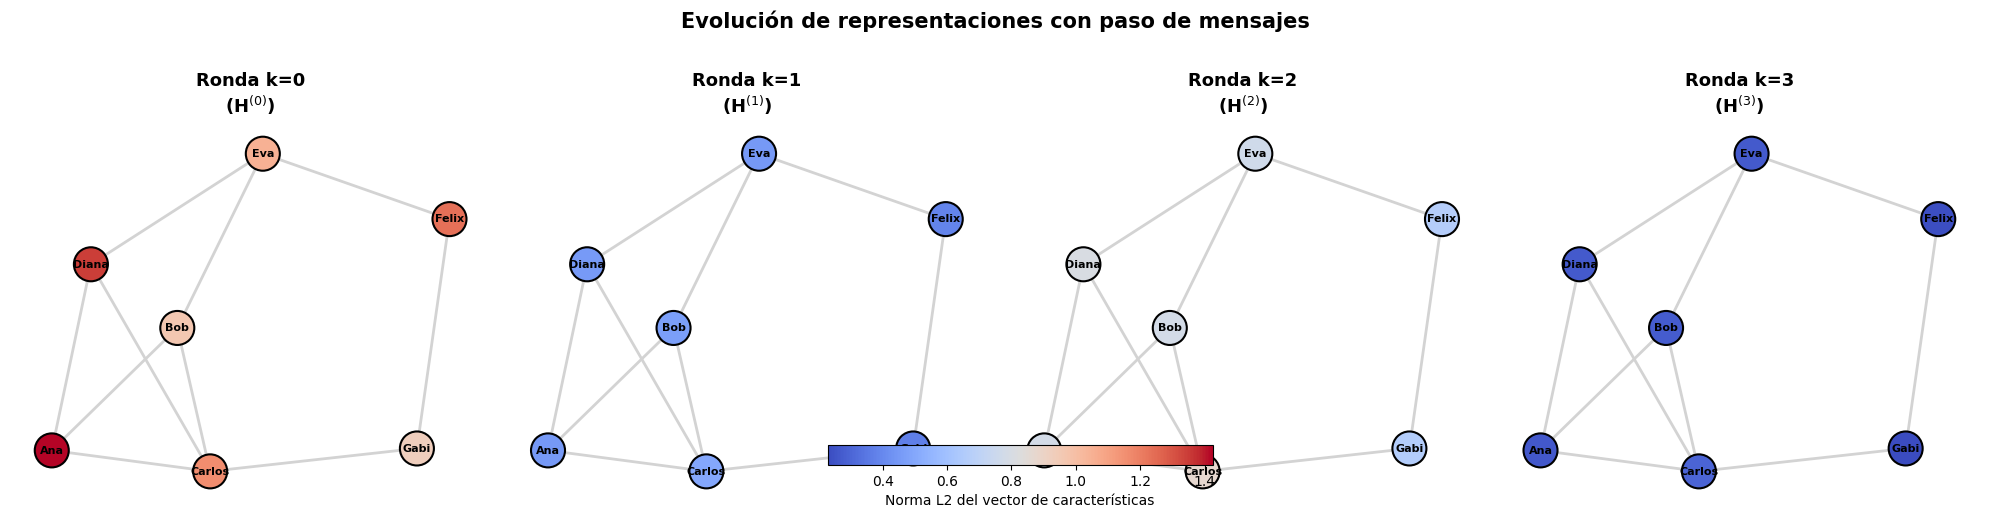

Observacion: A medida que aumentan las rondas, los nodos vecinos
tienden a tener colores más similares (comparten información).


In [10]:
# --- Visualización 1: Grafo coloreado por la primera dimensión ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Calculamos el rango global para que la escala de colores sea consistente
# Usamos la norma L2 del vector de cada nodo como "resumen" de la representación
todas_normas = []
for H in representaciones:
    normas = np.linalg.norm(H, axis=1)
    todas_normas.extend(normas)
vmin_global = min(todas_normas)
vmax_global = max(todas_normas)

for k, (ax, H) in enumerate(zip(axes, representaciones)):
    normas = np.linalg.norm(H, axis=1)
    
    nx.draw_networkx_edges(G, pos=pos, ax=ax, edge_color='lightgray', width=2)
    nodos_dibujados = nx.draw_networkx_nodes(
        G, pos=pos, ax=ax,
        node_color=normas, cmap=plt.cm.coolwarm,
        node_size=600, vmin=vmin_global, vmax=vmax_global,
        edgecolors='black', linewidths=1.5
    )
    nx.draw_networkx_labels(G, pos=pos, ax=ax, font_size=8, font_weight='bold')
    
    ax.set_title(f'Ronda k={k}\n(H$^{{({k})}}$)', fontsize=13, fontweight='bold')
    ax.axis('off')

# Barra de colores
fig.colorbar(nodos_dibujados, ax=axes, label='Norma L2 del vector de características',
             orientation='horizontal', fraction=0.05, pad=0.08, shrink=0.6)

fig.suptitle('Evolución de representaciones con paso de mensajes',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Observacion: A medida que aumentan las rondas, los nodos vecinos")
print("tienden a tener colores más similares (comparten información).")

/tmp/ipykernel_35363/35844724.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


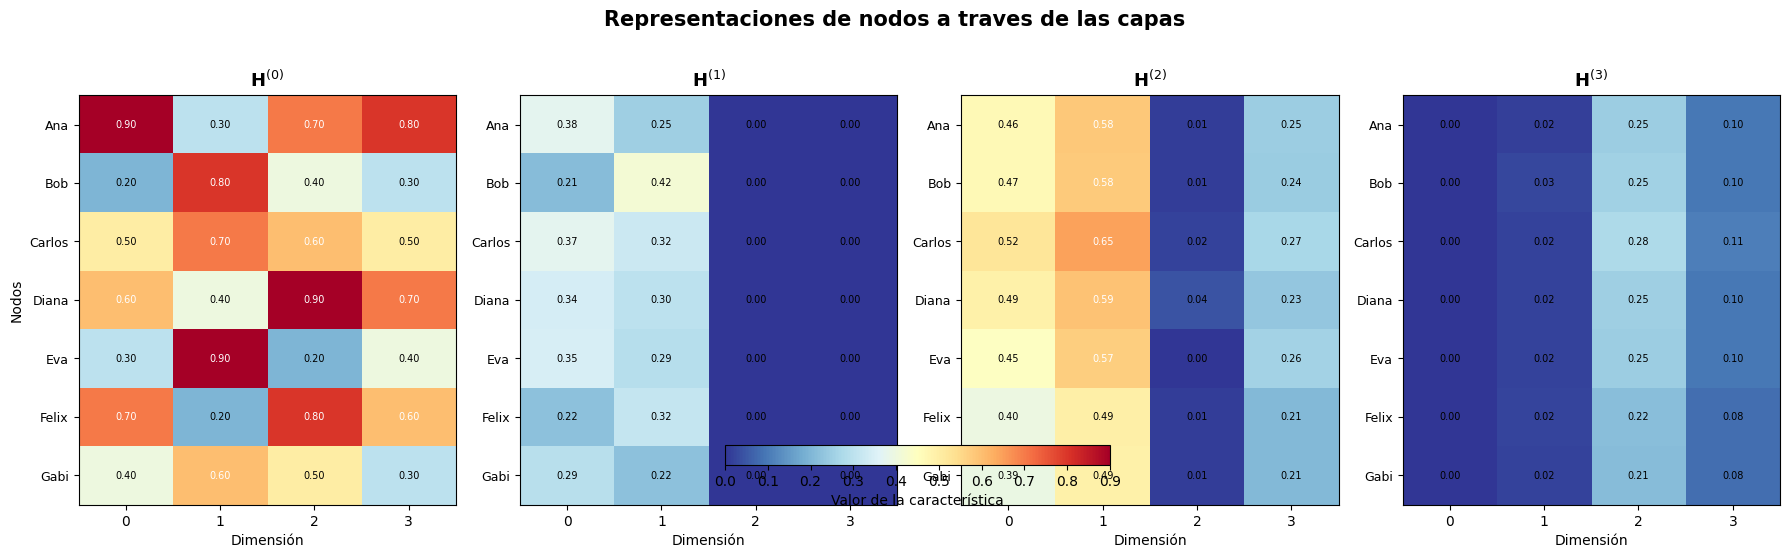

En H^(0), cada nodo tiene características unicas y distintas.
Con cada ronda de paso de mensajes, las representaciones van incorporando
información de vecinos cada vez más lejanos.


In [11]:
# --- Visualización 2: Heatmaps de las representaciones ---
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Rango global para consistencia en los colores
vmin_hm = min(H.min() for H in representaciones)
vmax_hm = max(H.max() for H in representaciones)

for k, (ax, H) in enumerate(zip(axes, representaciones)):
    im = ax.imshow(H, cmap='RdYlBu_r', aspect='auto', vmin=vmin_hm, vmax=vmax_hm)
    ax.set_yticks(range(num_nodos))
    ax.set_yticklabels(nodos, fontsize=9)
    ax.set_xticks(range(dim))
    ax.set_xlabel('Dimensión', fontsize=10)
    if k == 0:
        ax.set_ylabel('Nodos', fontsize=10)
    ax.set_title(f'H$^{{({k})}}$', fontsize=13, fontweight='bold')
    
    # Anotar los valores en las celdas
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            ax.text(j, i, f'{H[i,j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(H[i,j]) > (vmax_hm - vmin_hm) * 0.6 else 'black')

fig.colorbar(im, ax=axes, label='Valor de la característica',
             orientation='horizontal', fraction=0.05, pad=0.12, shrink=0.6)

fig.suptitle('Representaciones de nodos a traves de las capas',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("En H^(0), cada nodo tiene características unicas y distintas.")
print("Con cada ronda de paso de mensajes, las representaciones van incorporando")
print("información de vecinos cada vez más lejanos.")

### Análisis: campo receptivo y alcance de la información

Un aspecto fundamental del paso de mensajes es que en la ronda $k$, cada nodo recibe información de nodos que estan a lo sumo a $k$ saltos de distancia.

- **Ronda 1:** Cada nodo conoce a sus vecinos directos.
- **Ronda 2:** Cada nodo conoce a los vecinos de sus vecinos (2 saltos).
- **Ronda 3:** La información puede viajar hasta 3 saltos.

Veamos esto visualmente.

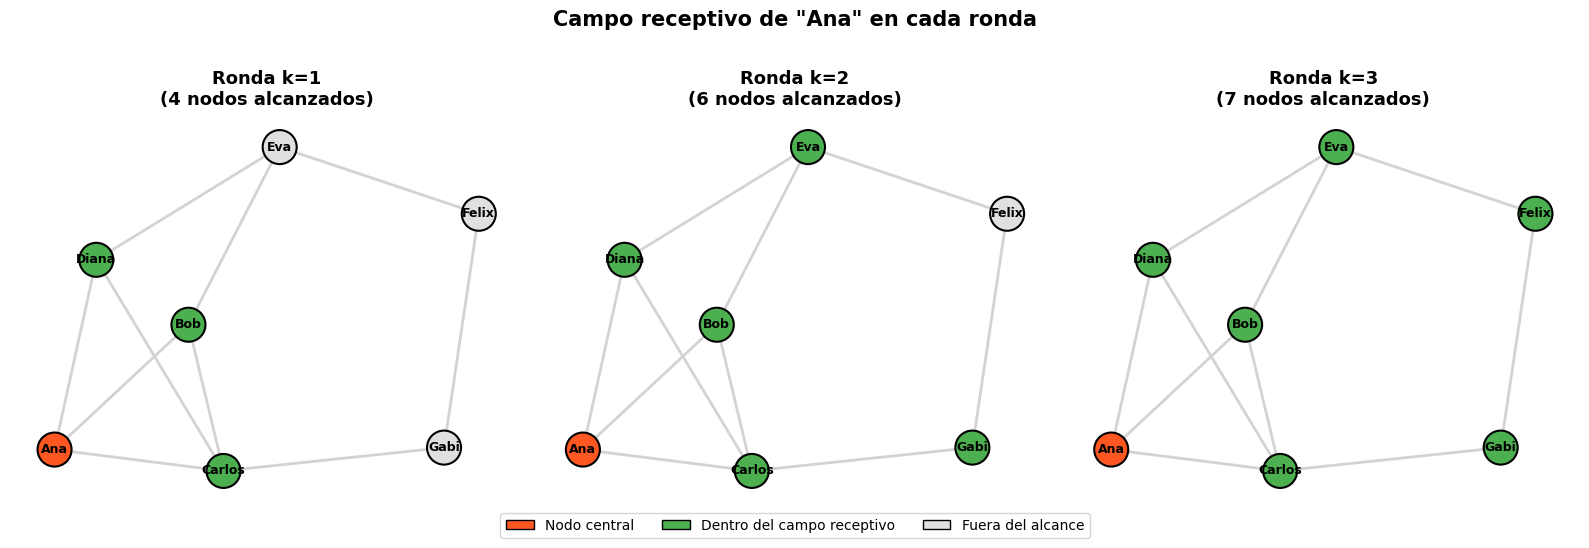

Despues de 3 rondas, Ana ha recibido información
de TODOS los nodos del grafo (ya que el diámetro del grafo es 3).


In [12]:
# Visualizar el campo receptivo de un nodo especifico (Ana)
nodo_central = 'Ana'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for k, ax in enumerate(axes, 1):
    # Calcular nodos a distancia <= k desde el nodo central
    distancias = nx.single_source_shortest_path_length(G, nodo_central)
    
    colores_nodo = []
    for nodo in nodos:
        d = distancias.get(nodo, float('inf'))
        if nodo == nodo_central:
            colores_nodo.append('#FF5722')   # Naranja: nodo central
        elif d <= k:
            colores_nodo.append('#4CAF50')   # Verde: dentro del campo receptivo
        else:
            colores_nodo.append('#E0E0E0')   # Gris: fuera del alcance
    
    nx.draw(G, pos=pos, ax=ax, node_color=colores_nodo, node_size=600,
            edge_color='lightgray', width=2, with_labels=True, font_size=9,
            font_weight='bold', edgecolors='black', linewidths=1.5)
    
    nodos_alcanzados = sum(1 for n in nodos if distancias.get(n, float('inf')) <= k)
    ax.set_title(f'Ronda k={k}\n({nodos_alcanzados} nodos alcanzados)',
                 fontsize=13, fontweight='bold')
    ax.axis('off')

fig.suptitle(f'Campo receptivo de "{nodo_central}" en cada ronda',
             fontsize=15, fontweight='bold', y=1.02)

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor='#FF5722', edgecolor='black', label='Nodo central'),
    Patch(facecolor='#4CAF50', edgecolor='black', label='Dentro del campo receptivo'),
    Patch(facecolor='#E0E0E0', edgecolor='black', label='Fuera del alcance'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

print(f"Despues de 3 rondas, {nodo_central} ha recibido información")
print(f"de TODOS los nodos del grafo (ya que el diámetro del grafo es {nx.diameter(G)}).")

### Paso 5: Midiendo la similitud entre nodos

Para cuantificar como las representaciones de los nodos van convergiendo (los vecinos se vuelven más similares), calculamos la **similitud coseno** entre todos los pares de nodos en cada ronda.

/tmp/ipykernel_35363/1730881443.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


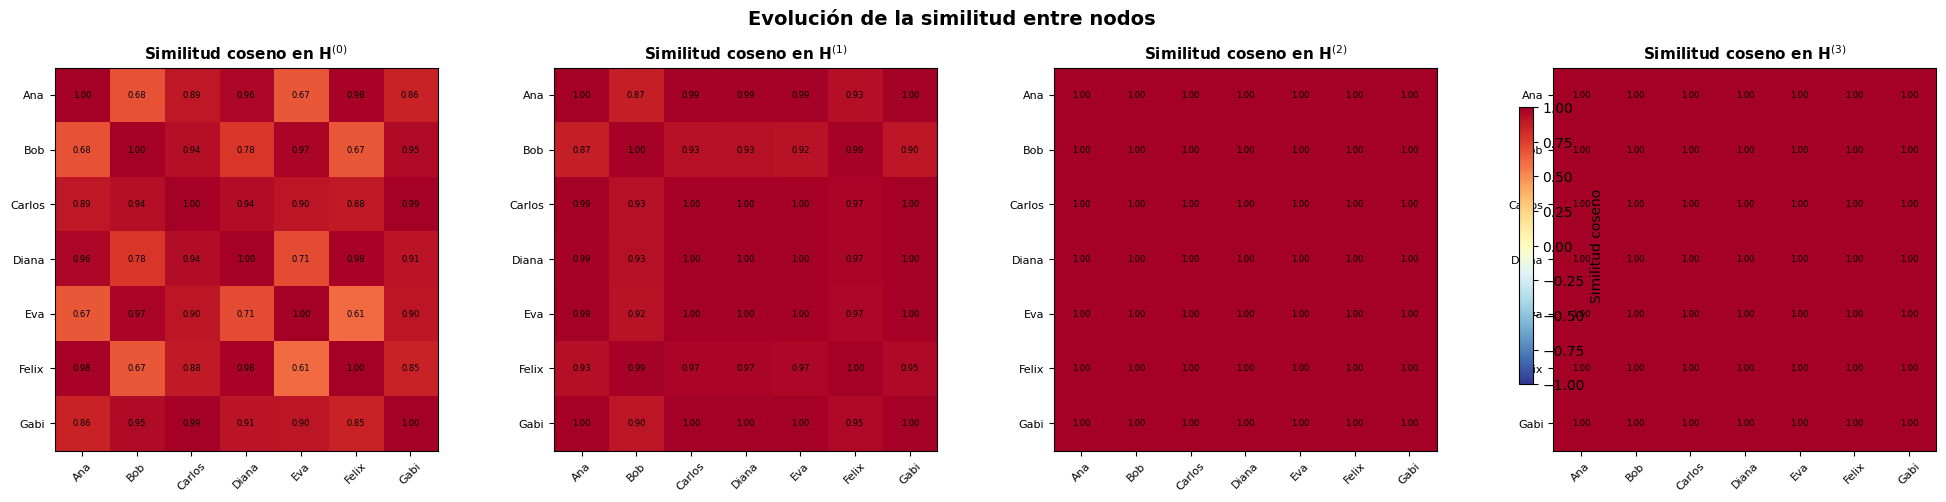


Similitud promedio entre nodos VECINOS vs. NO-VECINOS:
Ronda       Vecinos   No-vecinos   Diferencia
--------------------------------------------
k=0         0.8548       0.8626      -0.0078
k=1         0.9623       0.9715      -0.0092
k=2         0.9994       0.9996      -0.0002
k=3         0.9997       0.9997       0.0000

Nota: La diferencia positiva indica que los vecinos tienen representaciones
más similares entre si que los no-vecinos, como es deseable.


In [13]:
def similitud_coseno(H):
    """Calcula la matriz de similitud coseno entre todos los pares de nodos."""
    # Normalizar cada vector
    normas = np.linalg.norm(H, axis=1, keepdims=True)
    # Evitar división por cero
    normas = np.where(normas == 0, 1e-8, normas)
    H_norm = H / normas
    # Producto punto entre todos los pares
    return H_norm @ H_norm.T


fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for k, (ax, H) in enumerate(zip(axes, representaciones)):
    sim = similitud_coseno(H)
    im = ax.imshow(sim, cmap='RdYlBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(num_nodos))
    ax.set_xticklabels(nodos, rotation=45, fontsize=8)
    ax.set_yticks(range(num_nodos))
    ax.set_yticklabels(nodos, fontsize=8)
    ax.set_title(f'Similitud coseno en H$^{{({k})}}$', fontsize=11, fontweight='bold')
    
    # Anotar valores
    for i in range(num_nodos):
        for j in range(num_nodos):
            ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center', fontsize=6)

fig.colorbar(im, ax=axes, label='Similitud coseno', shrink=0.8)
fig.suptitle('Evolución de la similitud entre nodos',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Calcular la similitud promedio entre vecinos vs. no-vecinos
print("\nSimilitud promedio entre nodos VECINOS vs. NO-VECINOS:")
print(f"{'Ronda':<8} {'Vecinos':>10} {'No-vecinos':>12} {'Diferencia':>12}")
print("-" * 44)
for k, H in enumerate(representaciones):
    sim = similitud_coseno(H)
    # Vecinos: A[i,j] == 1
    # No-vecinos: A[i,j] == 0 y i != j
    sim_vecinos = sim[A == 1].mean()
    mascara_no_vecinos = (A == 0) & ~np.eye(num_nodos, dtype=bool)
    sim_no_vecinos = sim[mascara_no_vecinos].mean()
    print(f"k={k:<5} {sim_vecinos:>10.4f} {sim_no_vecinos:>12.4f} {sim_vecinos - sim_no_vecinos:>12.4f}")

print("\nNota: La diferencia positiva indica que los vecinos tienen representaciones")
print("más similares entre si que los no-vecinos, como es deseable.")

---
## Resumen de conceptos clave

En este módulo cubrimos los fundamentos de las Redes Neuronales de Grafos:

### 1. Datos en grafos vs. datos euclidianos
- Las CNN funcionan sobre cuadriculas regulares (imágenes), pero muchos datos reales tienen estructura de **grafo** ($G = (V, E)$).
- En un grafo, el número de vecinos varia por nodo y no existe un orden topológico fijo.

### 2. Paso de mensajes (*Message Passing*)
- Cada nodo actualiza su representación recogiendo y agregando información de sus vecinos.
- La ecuación general:

$$h_v^{(k)} = \sigma \left( W^{(k)} \cdot \text{COMBINE} \left( h_v^{(k-1)}, \text{AGG} \left( \{ h_u^{(k-1)} \}_{u \in \mathcal{N}(v)} \right) \right) \right)$$

### 3. Invarianza a permutaciones
- La operación de agregación **debe ser independiente del orden** de los vecinos.
- La concatenación **falla** porque depende del orden.
- Operaciones válidas: **suma** ($\sum$), **media** ($\mu$), **máximo** ($\max$).

### 4. Campo receptivo
- Despues de $k$ rondas de paso de mensajes, cada nodo ha incorporado información de nodos a $k$ saltos de distancia.
- Los nodos vecinos tienden a desarrollar representaciones más similares entre si.

### Pregunta para reflexionar

> *Qué pasaría si apilamos muchas capas de paso de mensajes (por ejemplo 10, 20, o 50)?*
> *Eventualmente todos los nodos recibirian información de todo el grafo... Sería esto beneficioso o perjudicial?*

Esta pregunta nos llevara al **Módulo 2: El problema del over-smoothing (sobre-suavizado)**.

---

### Referencias

- Aggarwal, C. C. (2023). *Neural Networks and Deep Learning* (2nd ed.), Cap. 10. Springer.
- Hamilton, W., Ying, Z., & Leskovec, J. (2017). *Inductive Representation Learning on Large Graphs (GraphSAGE)*. NeurIPS.
- Kipf, T. N. & Welling, M. (2017). *Semi-Supervised Classification with Graph Convolutional Networks*. ICLR.